In [47]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
import Modeling.models.beam_properties as beam_properties_module
importlib.reload(beam_properties_module)
PiezoBeamParams = beam_properties_module.PiezoBeamParams
from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM
import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module
# import Modeling.models.ROM as ROM_module
# importlib.reload(ROM_module)
# ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
# K_i = 8000*0.928; K_p = 0.015; K_c =e10; R_c = 1e3
K_i = 1820; K_p = 0.004; K_c = -3e10; R_c = 1e3
K_i = 0; K_p = 100000; K_c = 0; R_c = 1e3
K_i = 0; K_p = 1e-5; K_c = 0; R_c = 1e3
t_end = 0.005
f0 = 100
f1 = 4500
dt = 1/f1/20
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
# N = 40
# hp, hs = 0.31e-3, 0.607e-3 	
# zeta_dict = { 1: 0.02, 2: 0.025, 3: 0.03, 4: 0.007, 5: 0.0075, 6:0.0085, 7:0.008, 8:0.007,
# 			 9: 0.007, 10: 0.0075, 11: 0.008, 12: 0.009, 13: 0.01, 14: 0.012, 15: 0.016, 16: 0.017,
# 			 17: 0.02, 18:0.03, 19:0.03,'rest': 0.6
# 			 } # dummy values for now

params_fe = PiezoBeamParams(
                            hp=0.252e-3, hs=0.51e-3,
                            # hp=0.31e-3, hs=0.607e-3,
                            d31= -1.45e-10,eps_r=1700,
							# rho_p=7700,
							# omega_p=2*pi*100, omega_q=2*pi*5000,
							# zeta_dict = zeta_dict
                            )
# params_fe.zeta_p = 0.0001
# params_fe.zeta_q = 0.0001
# params_fe.zeta_p = 0.15
# params_fe.zeta_q = 0.1
# params_fe.plot_zeta_vs_omega()


In [48]:

def print_derived_params(params_fe):
	print("=== Derived / Calibrated Parameters ===")

	print(f"S (number of patches)        = {params_fe.S}")
	print(f"L_b (beam length) [m]        = {params_fe.L_b:.6f}")

	print("\n--- Electromechanical ---")
	print(f"e31 (effective) [C/m^2]      = {params_fe.e31:.4e}")
	print(f"theta_mech (vartheta) [SI]   = {params_fe.theta_mech:.4e}")
	print(f"Cp (per patch) [F]           = {params_fe.Cp_scalar:.4e}")

	print("\n--- Mechanical ---")
	print(f"m (mass/length) [kg/m]       = {params_fe.m:.4f}")
	print(f"m substrate (mass/length) [kg/m]       = {params_fe.rho_s * params_fe.hs * params_fe.b:.4f}")
	print(f"YI (bending stiffness) [Nm²] = {params_fe.YI:.4e}")

	print("\n--- Damping (Rayleigh) ---")
	print(f"omega_p [Hz]                 = {params_fe.omega_p/(2*np.pi):.2f}")
	print(f"omega_q [Hz]                 = {params_fe.omega_q/(2*np.pi):.2f}")
	print(f"zeta_p [-]                   = {params_fe.zeta_p:.4f}")
	print(f"zeta_q [-]                   = {params_fe.zeta_q:.4f}")
	print(f"c_alpha [SI]                 = {params_fe.c_alpha:.4e}")
	print(f"c_beta  [SI]                 = {params_fe.c_beta:.4e}")
	

# print_derived_params(params_fe)

# ============================================================================
# FE SYSTEM SETUP
# ============================================================================

fe = FE.PiezoBeamFE(params_fe
					# , n_el_gap=3, n_el_patch=5
					)

ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,
    K_i=K_i,
    K_p=K_p,
    v_exc=v_exc
)

# ============================================================================
# FREQUENCY-DOMAIN ANALYSIS
# ============================================================================

f_fe = np.linspace(f0, f1, 1000)
# frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*pi)
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*pi)

fe_freq_domain = { # Transmissibility FRF, normalized by the amplitude of the excitation point (last DOF)
    "freq": frf_fd['freq'],
    # "velocity": np.mean(np.abs(frf_fd['u_dot'])**2, axis=1)**0.5/np.mean(np.abs(frf_fd['u_dot'][:,-2:])**2, axis=1)**0.5
	"velocity": np.mean(np.abs(frf_fd['u_dot']), axis=1)
}
print("Eigenfrequencies (Hz):", fe.freq)

FRF sweep: 100%|██████████| 1000/1000 [00:07<00:00, 136.47it/s]


Eigenfrequencies (Hz): [5.31964176e+00 3.33353242e+01 9.33329271e+01 1.82880950e+02
 3.02295479e+02 4.51550299e+02 6.30644769e+02 8.39577446e+02
 1.07834723e+03 1.34695404e+03 1.64539792e+03 1.97367909e+03
 2.33179697e+03 2.71974886e+03 3.13752867e+03 3.58512446e+03
 4.06251597e+03 4.56966997e+03 5.10653380e+03 5.67302544e+03
 6.26901822e+03 6.89431647e+03 7.54861488e+03 8.23142734e+03
 8.94195500e+03 9.67882342e+03 1.04395109e+04 1.12189585e+04
 1.20056806e+04 1.27689412e+04 1.34126928e+04 1.56429025e+04
 1.63016059e+04 1.71700125e+04 1.81345412e+04 1.91573649e+04
 2.02246876e+04 2.13305682e+04 2.24720786e+04 2.36476181e+04
 2.48562359e+04 2.60973250e+04 2.73704698e+04 2.86753633e+04
 3.00117564e+04 3.13794256e+04 3.27781462e+04 3.42076678e+04
 3.56676883e+04 3.71578190e+04 3.86775382e+04 4.02261216e+04
 4.18025334e+04 4.34052495e+04 4.50319539e+04 4.66789908e+04
 4.83403139e+04 5.00053252e+04 5.16540673e+04 5.32456590e+04
 5.46894998e+04 5.57862139e+04 6.25652905e+04 6.35987616e+04
 

In [49]:
# print("Phi shape:", fe.Phi.shape)
# print("M_red shape:", fe.M_red.shape)
# print("K_red shape:", fe.K_red.shape)
# # print("C_red shape:", fe.C_red.shape)
# print("fr omega shape:", fe.omega.shape)
# print("zeta shape:", zeta.shape)

# C_modal = 2 * zeta * fe.omega
# # C_red = self.Phi[self.free_dofs, :].T @ (self.params.c_alpha*self.M + self.params.c_beta*self.K) @ self.Phi[self.free_dofs, :]
# C_modal_matrix = np.diag(C_modal)
# # C_reconstructed = np.linalg.inv( fe.Phi).T @ C_modal_matrix @ np.linalg.inv(fe.Phi)

In [50]:

# ============================================================================
# TIME-DOMAIN TRANSIENT ANALYSIS
# ============================================================================

ndof = ode.M.shape[0]
result = FE_helpers.solve_newmark(
    ode=ode,
    dt=dt,
    t_end=t_end,
    beta=0.25,
    gamma=0.5,
    newton_tol=1e-8,
    newton_maxiter=8,
    x0=np.zeros(ndof),
    x_dot0=np.zeros(ndof)
)

fe_time_domain = {
    "t": result['t'],
    "displacement": result['u'],
    "velocity": result['u_dot'],
    'frf': np.abs(result['spectral']['FRF']),
    'freq': result['spectral']['freq']
}

# ============================================================================
# EXPERIMENTAL DATA LOADING
# ============================================================================

def load_experimental_dataset(npz_path, name):
    """Load experimental data from npz file without assuming structure."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            loaded_dict = {key: data[key] for key in data.files}
            loaded_dict["status"] = "loaded"
            loaded_dict["name"] = name
            return loaded_dict
    except Exception as e:
        print(f"Warning: {name} data not loaded - {e}")
        return {
            "name": name,
            "status": "failed",
            "error": str(e)
        }

npz_paths = {
    "OC": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz",
    "SC": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz",
    "SC2": r"Z:/Nima/Synthetic_impedance/long_beam/ssdsl_dat/locat_dat_Feb2026/19\lowFreq_SC.npz",
    "Linear": r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz",
    "Local" : r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\21\Local.npz",
}

exp_data = {}
for name, path in npz_paths.items():
    exp_data[name] = load_experimental_dataset(path.replace("\\", "/"), name)

print("\nAvailable keys in each experimental dataset:")
for name, data in exp_data.items():
    if data.get("status") == "loaded":
        keys = [k for k in data.keys() if k not in ["status", "name"]]
        print(f"  {name}: {keys}")

# ============================================================================
# REFERENCE DATA (COMSOL)
# ============================================================================

import io
import re

def _read_comsol_text_like(file_path):
    """Read COMSOL text export with '%' metadata/header and whitespace-separated numeric columns."""
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    comment_lines = [ln.strip() for ln in lines if ln.lstrip().startswith('%')]
    header_line = None
    for ln in reversed(comment_lines):
        candidate = ln.lstrip('%').strip()
        if ':' in candidate:
            continue
        if re.search(r'[A-Za-z]', candidate):
            header_line = candidate
            break

    data_lines = [ln for ln in lines if ln.strip() and not ln.lstrip().startswith('%')]
    if not data_lines:
        raise ValueError("No numeric data rows found in text COMSOL file")

    df = pd.read_csv(
        io.StringIO(''.join(data_lines)),
        sep=r'\s+',
        header=None,
        engine='python'
    )

    if header_line is not None:
        parsed_cols = [c.strip() for c in re.split(r'\s{2,}', header_line) if c.strip()]
        if len(parsed_cols) == df.shape[1]:
            df.columns = parsed_cols
        elif df.shape[1] == 2:
            df.columns = ["freq (Hz)", "Simulation (m)"]
    elif df.shape[1] == 2:
        df.columns = ["freq (Hz)", "Simulation (m)"]

    return df

def load_comsol_dataset(file_path, name):
    """Load one COMSOL dataset and return a DataFrame directly."""
    try:
        ext = Path(file_path).suffix.lower()
        if ext == ".csv":
            df = pd.read_csv(file_path)
        elif ext in {".txt", ".txc", ".dat"}:
            df = _read_comsol_text_like(file_path)
        else:
            try:
                df = pd.read_csv(file_path)
            except Exception:
                df = _read_comsol_text_like(file_path)

        return df
    except Exception as e:
        print(f"Warning: COMSOL {name} data not loaded - {e}")
        return pd.DataFrame(columns=["freq (Hz)", "Simulation (m)"])

comsol_paths = {
    "SC_csv": '../../../comsol/SC.csv',
    "SC_modalDamp_txt": '../../../comsol/SC_modalDamp_sim.txt',
    # "SC_modalDamp_txc": '../../../comsol/SC_modalDamp_sim.txc',
    # "OC": '../../../comsol/OC.csv',
    # "LR": '../../../comsol/LR.csv',
}

# IMPORTANT: values are DataFrames so plotting can use comsol_data["name"]["column"] directly
comsol_data = {}
for name, path in comsol_paths.items():
    comsol_data[name] = load_comsol_dataset(path.replace("\\", "/"), name)

print("\nAvailable columns in each COMSOL dataset:")
for name, df in comsol_data.items():
    print(f"  {name}: {list(df.columns)}")

# Backward compatibility alias
comsol = comsol_data.get("SC_csv", None)

print("\n✓ Data loading complete")
print(f"  FE freq-domain:  {fe_freq_domain['freq'].shape}")
print(f"  FE time-domain:  {fe_time_domain['t'].shape}")
for name, data in exp_data.items():
    if data['status'] == 'loaded':
        print(f"  Experimental {name}: {data['freq'].shape}")
    else:
        print(f"  Experimental {name}: FAILED")

for name, df in comsol_data.items():
    print(f"  COMSOL {name}: {df.shape}")


Newmark Integration: 100%|██████████| 450/450 [00:01<00:00, 334.69step/s]


X shape: (451,) Y shape: (451, 157) freq shape: (451,) veloc shape: (451, 157)

Available keys in each experimental dataset:
  OC: ['freq', 'frf_data']
  SC: ['freq', 'frf_mag', 'frf_phase', 'meas_points']
  SC2: ['freq', 'frf_mag', 'frf_phase', 'meas_points']
  Linear: ['freq', 'frf_data']
  Local: ['freq', 'frf_mag', 'frf_phase', 'meas_points']

Available columns in each COMSOL dataset:
  SC_csv: ['freq', 'w']
  SC_modalDamp_txt: ['freq (Hz)', 'Simulation (m)']

✓ Data loading complete
  FE freq-domain:  (1000,)
  FE time-domain:  (451,)
  Experimental OC: (9473,)
  Experimental SC: (9473,)
  Experimental SC2: (1441,)
  Experimental Linear: (9473,)
  Experimental Local: (5377,)
  COMSOL SC_csv: (1800, 2)
  COMSOL SC_modalDamp_txt: (2951, 2)


In [51]:
fe_freq_domain['velocity'] 

array([7.90789181e-06, 5.06648107e-06, 4.06333599e-06, 3.61508054e-06,
       3.40440758e-06, 3.31855295e-06, 3.31097145e-06, 3.36041755e-06,
       3.45583828e-06, 3.60162131e-06, 3.79954464e-06, 4.05153208e-06,
       4.37166220e-06, 4.79272736e-06, 5.35564736e-06, 6.14145148e-06,
       7.31727768e-06, 9.35363352e-06, 1.33485247e-05, 2.41426519e-05,
       8.69216535e-05, 3.14041459e-05, 1.64266234e-05, 1.18936667e-05,
       9.80666949e-06, 8.66958341e-06, 7.98467888e-06, 7.55626626e-06,
       7.28871211e-06, 7.14897694e-06, 7.10211403e-06, 7.13577996e-06,
       7.22657362e-06, 7.37287345e-06, 7.58618635e-06, 7.86327318e-06,
       8.21458852e-06, 8.66554350e-06, 9.22330769e-06, 9.92483513e-06,
       1.08207356e-05, 1.19753758e-05, 1.35223947e-05, 1.56933529e-05,
       1.90288536e-05, 2.46215927e-05, 3.53276901e-05, 6.23003304e-05,
       1.43834343e-04, 7.32512407e-05, 3.94497163e-05, 2.78197190e-05,
       2.21505327e-05, 1.89523386e-05, 1.69285766e-05, 1.55496853e-05,
      

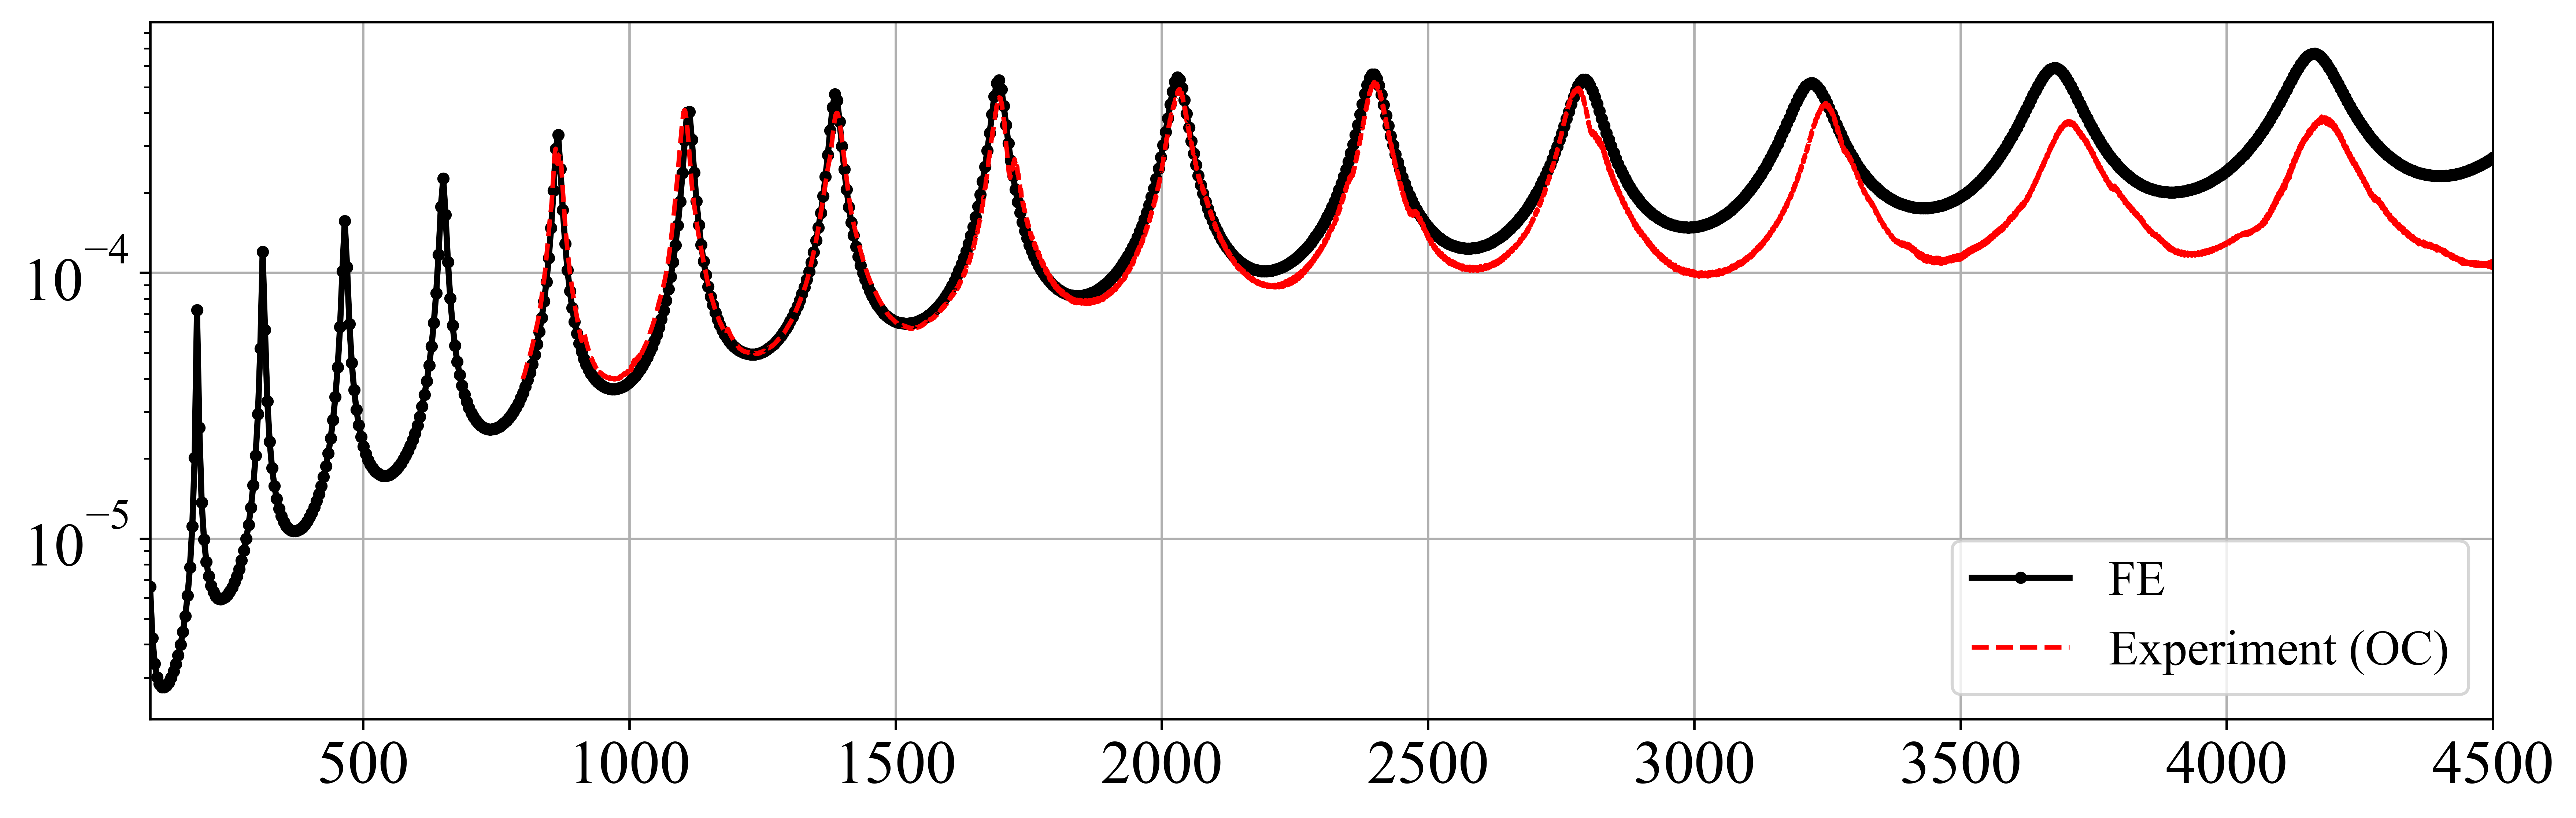

In [56]:

# %matplotlib widget

plt.figure(figsize=(12, 4))
plt.semilogy(fe_freq_domain['freq'], fe_freq_domain['velocity']/1.2, 'k.-', lw=2, label='FE ')
# plt.semilogy(fe_time_domain['freq'], fe_time_domain['frf']/1.2, '.-', label='FE time-domain')
# Experimental data (uncomment as needed)
plt.semilogy(exp_data["OC"]["freq"], np.mean(exp_data["OC"]["frf_data"], axis=1)#/exp_data["OC"]["frf_mag"][:, -3]
             , 'r--', label='Experiment (OC)')

subset = (exp_data["SC2"]["freq"] <= 800)
# plt.semilogy(exp_data["SC"]["freq"], np.mean(exp_data["SC"]["frf_mag"], axis=1)#/exp_data["SC"]["frf_mag"][:, -3]
#              , 'r--', label='Experiment (SC)')
# plt.semilogy(exp_data["SC2"]["freq"][subset], np.mean(exp_data["SC2"]["frf_mag"][subset, :], axis=1)*20#/np.mean(exp_data["SC2"]["frf_mag"][:, -4:]**2, axis=1)**0.5
#              , 'r--'
#             #  , label='Experiment (SC2)'
#              )
# plt.semilogy(exp_data["Linear"]["freq"], np.mean(exp_data["Linear"]["frf_data"], axis=1), 'r--', label='Experiment ')
# plt.semilogy(exp_data["Local"]["freq"], np.mean(exp_data["Local"]["frf_mag"]*20, axis=1), 'b--', label='Experiment local ')
# COMSOL reference (uncomment if available)
# plt.semilogy(comsol_data["SC_modalDamp_txt"]['freq (Hz)'], 1.2*comsol_data["SC_modalDamp_txt"]['Simulation (m)']*2*np.pi*comsol_data["SC_modalDamp_txt"]['freq (Hz)'], 'g-', label='COMSOL')

# plt.xlabel('Frequency [Hz]')
# plt.ylabel('Velocity / Voltage FRF \n $[m/(V.s)]$')
plt.xlim([f0, f1])
# plt.xlim([1200, 3000])
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.ylim([1e-5, 8e-4])
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.dpi": 600,
    "font.family": "serif",
    "font.serif": "Times New Roman",
})
plt.show()

# OC SC conlusion figure

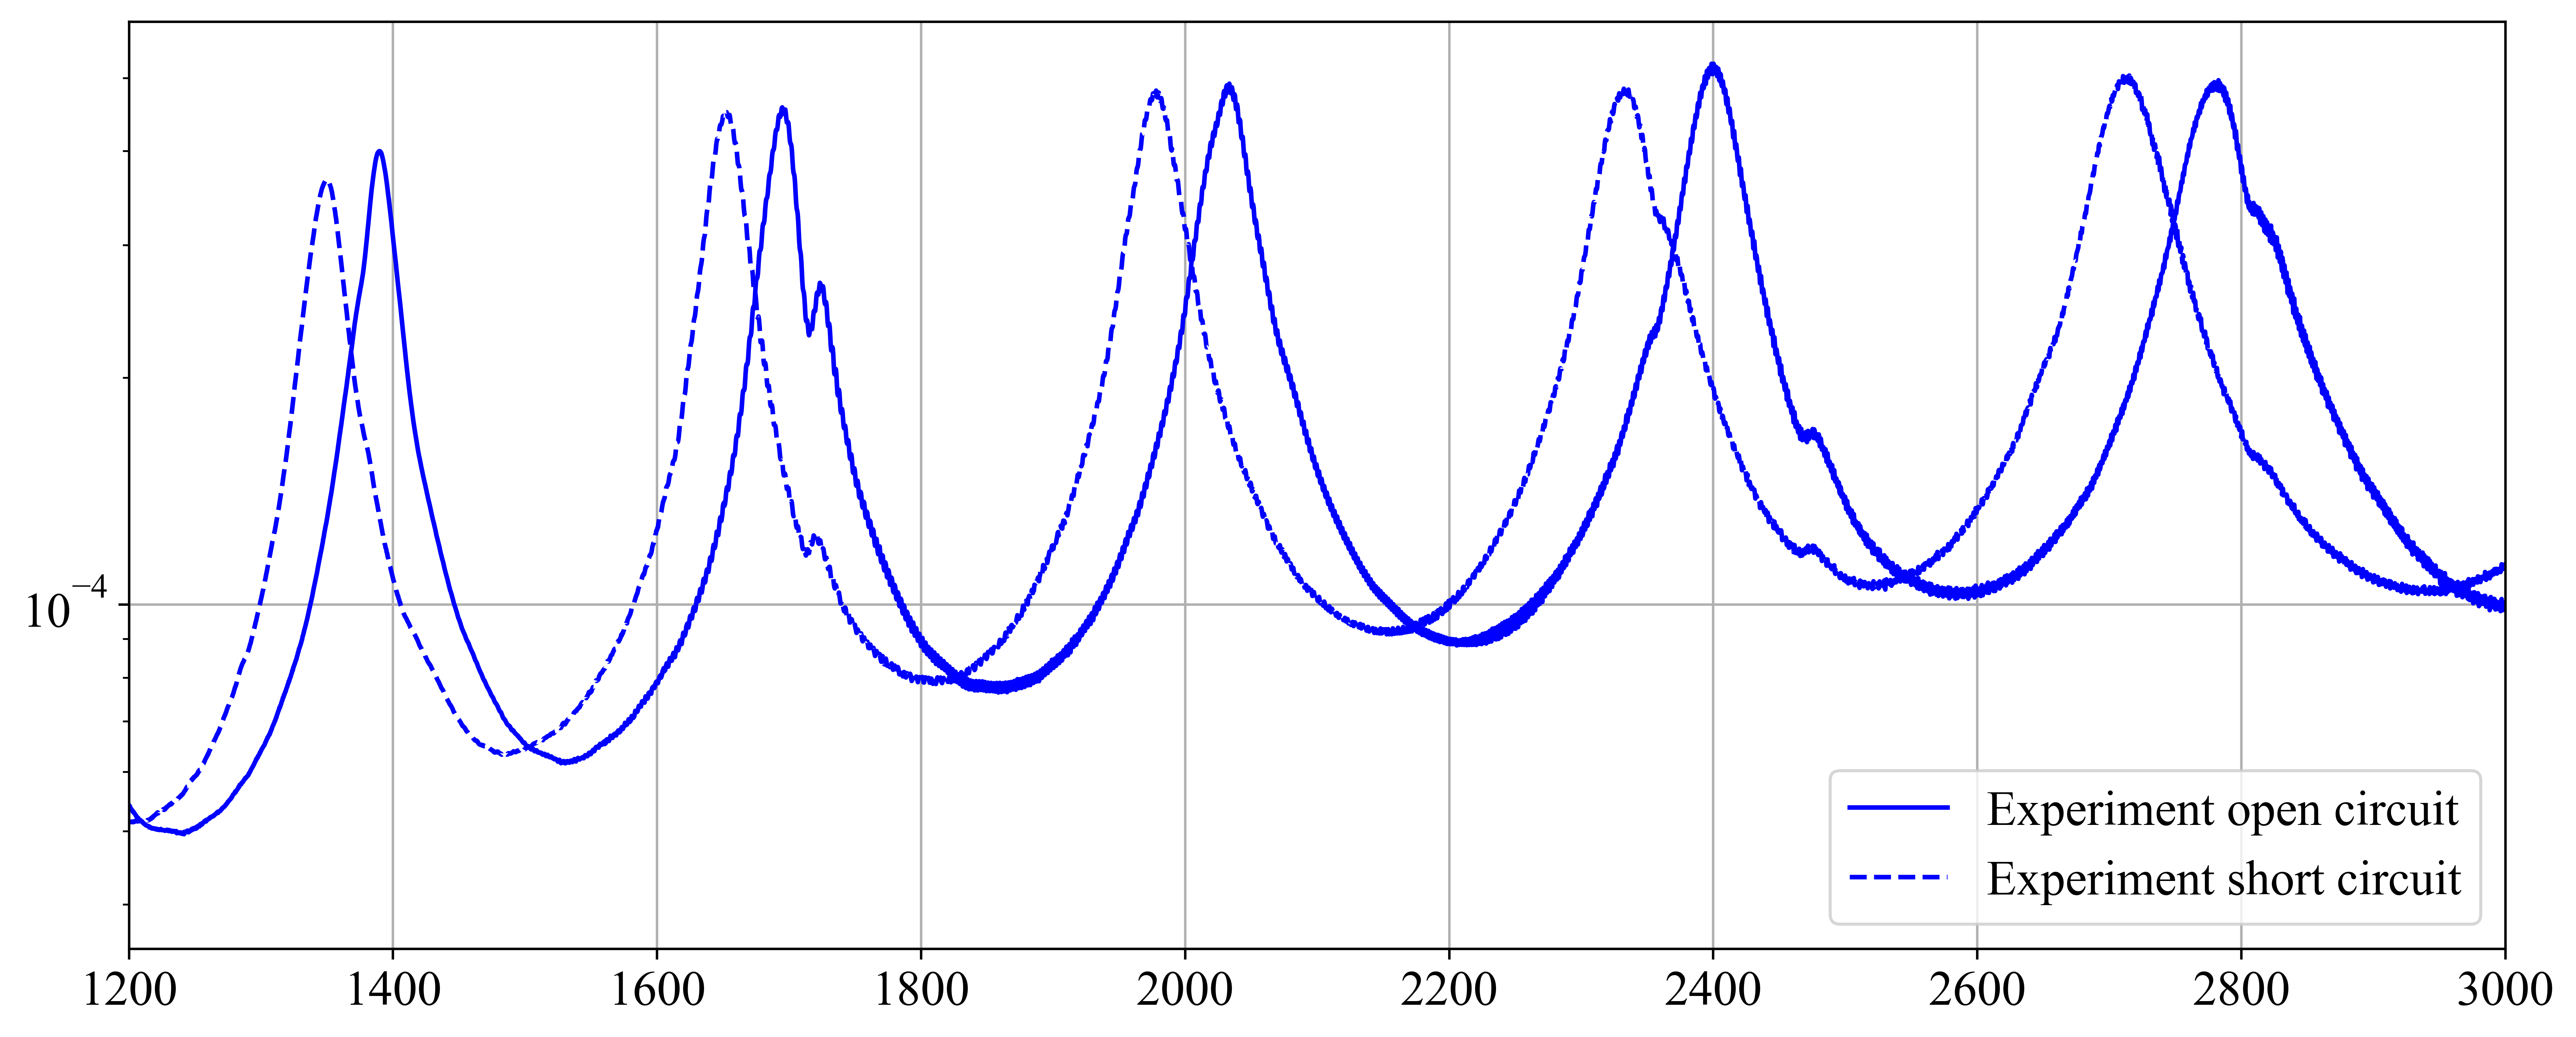

In [53]:

# %matplotlib widget

plt.figure(figsize=(12, 5))
# plt.semilogy(fe_freq_domain['freq'], fe_freq_domain['velocity']/1.2, 'k.-', lw=2, label='FE ')
# plt.semilogy(fe_time_domain['freq'], fe_time_domain['frf']/1.2, '.-', label='FE time-domain')
# Experimental data (uncomment as needed)
plt.semilogy(exp_data["OC"]["freq"], np.mean(exp_data["OC"]["frf_data"], axis=1)#/exp_data["OC"]["frf_mag"][:, -3]
             , 'b-', label='Experiment open circuit')

subset = (exp_data["SC2"]["freq"] <= 800)
plt.semilogy(exp_data["SC"]["freq"], np.mean(exp_data["SC"]["frf_mag"], axis=1)#/exp_data["SC"]["frf_mag"][:, -3]
             , 'b--', label='Experiment short circuit')
# plt.semilogy(exp_data["SC2"]["freq"][subset], np.mean(exp_data["SC2"]["frf_mag"][subset, :], axis=1)*20#/np.mean(exp_data["SC2"]["frf_mag"][:, -4:]**2, axis=1)**0.5
#              , 'r--'
#             #  , label='Experiment (SC2)'
#              )
# plt.semilogy(exp_data["Linear"]["freq"], np.mean(exp_data["Linear"]["frf_data"], axis=1), 'r--', label='Experiment ')
# plt.semilogy(exp_data["Local"]["freq"], np.mean(exp_data["Local"]["frf_mag"]*20, axis=1), 'b--', label='Experiment local ')
# COMSOL reference (uncomment if available)
# plt.semilogy(comsol_data["SC_modalDamp_txt"]['freq (Hz)'], 1.2*comsol_data["SC_modalDamp_txt"]['Simulation (m)']*2*np.pi*comsol_data["SC_modalDamp_txt"]['freq (Hz)'], 'g-', label='COMSOL')

# plt.xlabel('Frequency [Hz]')
# plt.ylabel('Velocity / Voltage FRF \n $[m/(V.s)]$')
plt.xlim([f0, f1])
plt.xlim([1200, 3000])
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.ylim([1e-5, 8e-4])
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "figure.dpi": 600,
    "font.family": "serif",
    "font.serif": "Times New Roman",
})
plt.show()

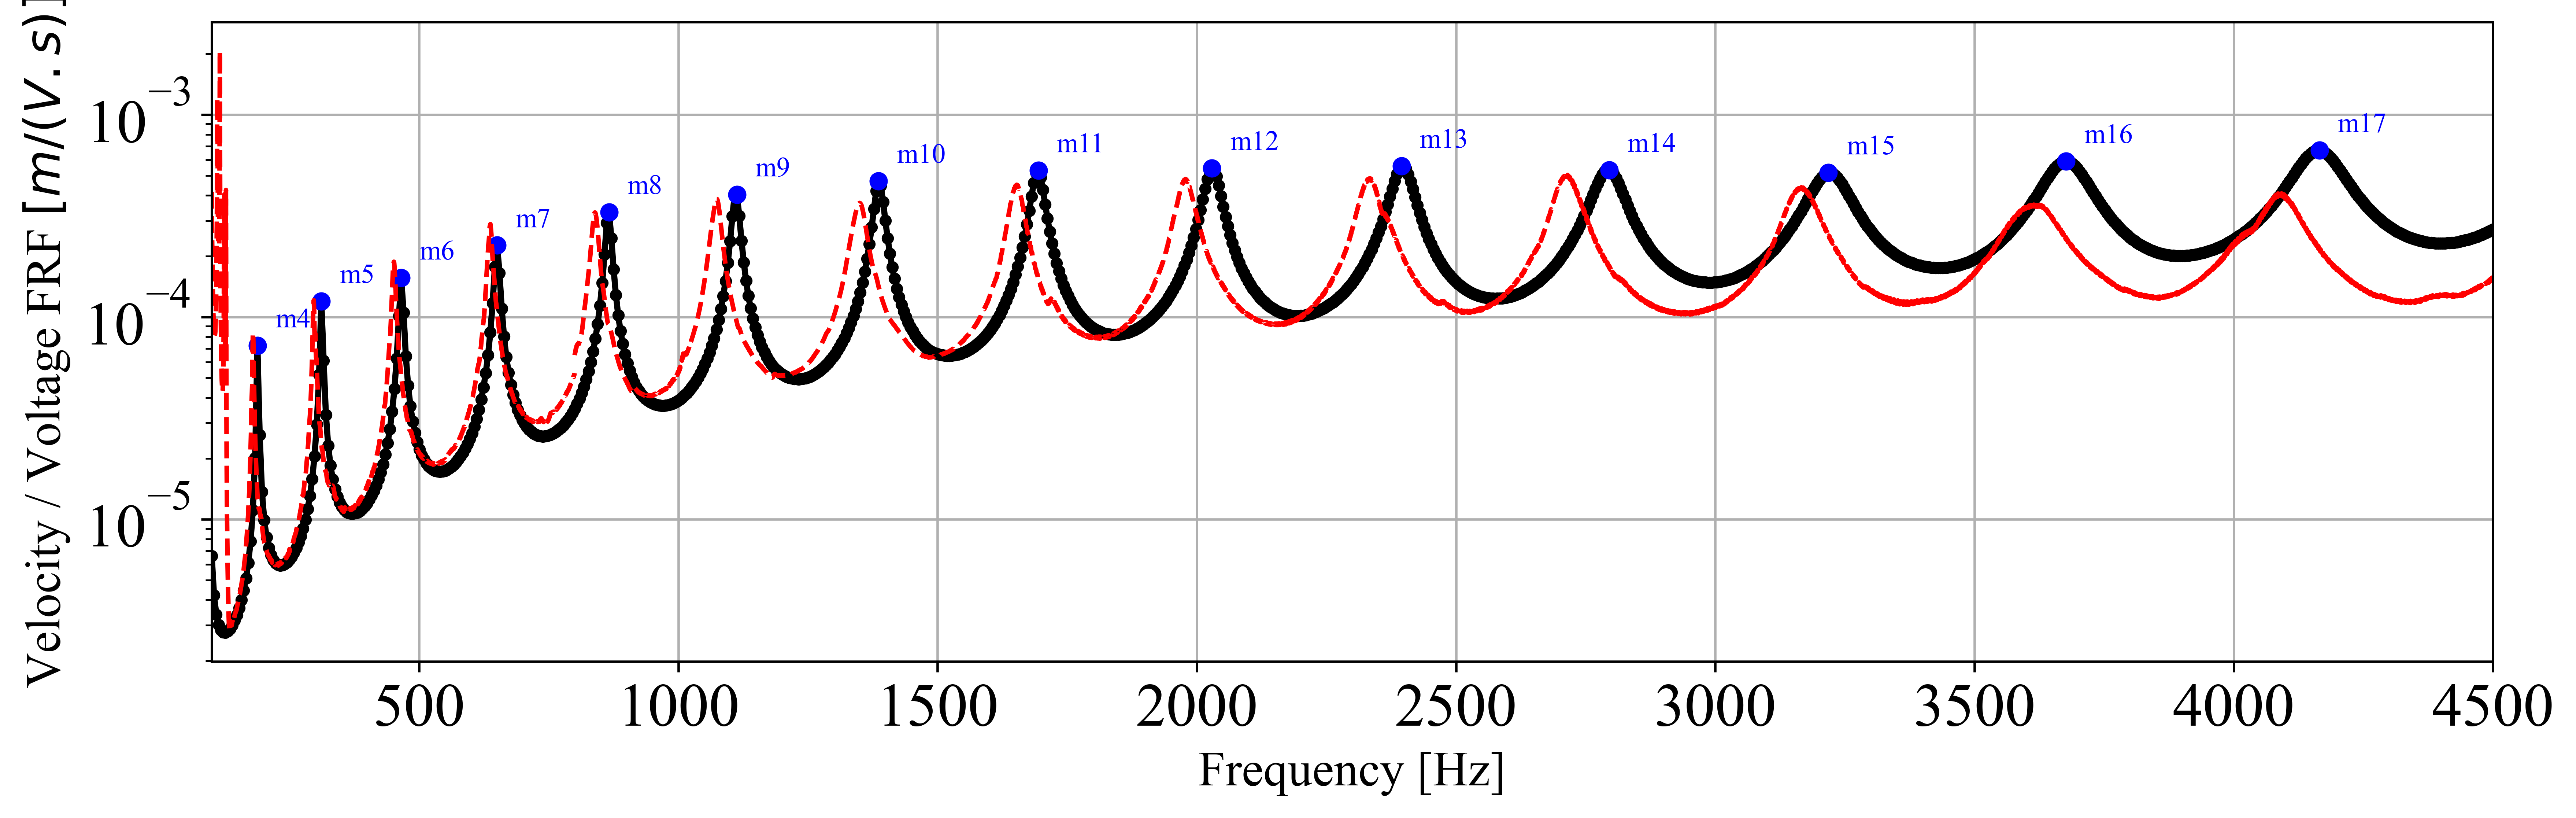

Peak-to-mode mapping (nearest in fe.freq):
Peak  1: f_peak =   188.09 Hz  ->  mode m 4 (f_eig =   182.88 Hz)
Peak  2: f_peak =   311.41 Hz  ->  mode m 5 (f_eig =   302.30 Hz)
Peak  3: f_peak =   465.57 Hz  ->  mode m 6 (f_eig =   451.55 Hz)
Peak  4: f_peak =   650.55 Hz  ->  mode m 7 (f_eig =   630.64 Hz)
Peak  5: f_peak =   866.37 Hz  ->  mode m 8 (f_eig =   839.58 Hz)
Peak  6: f_peak =  1113.01 Hz  ->  mode m 9 (f_eig =  1078.35 Hz)
Peak  7: f_peak =  1386.09 Hz  ->  mode m10 (f_eig =  1346.95 Hz)
Peak  8: f_peak =  1694.39 Hz  ->  mode m11 (f_eig =  1645.40 Hz)
Peak  9: f_peak =  2029.13 Hz  ->  mode m12 (f_eig =  1973.68 Hz)
Peak 10: f_peak =  2394.69 Hz  ->  mode m13 (f_eig =  2331.80 Hz)
Peak 11: f_peak =  2795.50 Hz  ->  mode m14 (f_eig =  2719.75 Hz)
Peak 12: f_peak =  3218.32 Hz  ->  mode m15 (f_eig =  3137.53 Hz)
Peak 13: f_peak =  3676.38 Hz  ->  mode m16 (f_eig =  3585.12 Hz)
Peak 14: f_peak =  4165.27 Hz  ->  mode m17 (f_eig =  4062.52 Hz)


In [54]:
# Annotate FE FRF peaks with eigen-spectrum mode numbers (from fe.freq)
from scipy.signal import find_peaks

freq = np.asarray(fe_freq_domain['freq'], dtype=float)
frf = np.asarray(fe_freq_domain['velocity'], dtype=float) / 1.2

# Sort eigenfrequencies and keep their original mode numbering
eig_freq = np.asarray(fe.freq, dtype=float).ravel()
eig_order = np.argsort(eig_freq)
eig_sorted = eig_freq[eig_order]

# Peak detection (tune prominence/distance if needed)
peak_idx, _ = find_peaks(frf, prominence=0.03*np.max(frf), distance=8)
peak_freq = freq[peak_idx]
peak_mag = frf[peak_idx]

# Map each FRF peak to nearest eigenfrequency number in the sorted eigen spectrum
nearest_sorted_idx = np.array([np.argmin(np.abs(eig_sorted - pf)) for pf in peak_freq])
mode_number = nearest_sorted_idx + 1  # 1-based mode index in eigen spectrum

plt.figure(figsize=(12, 4))
plt.semilogy(freq, frf, 'k.-', lw=2, label='FE freq-domain')
plt.semilogy(peak_freq, peak_mag, 'bo', ms=5, label='Detected peaks')
plt.semilogy(exp_data["SC"]["freq"], np.mean(exp_data["SC"]["frf_mag"], axis=1)#/exp_data["SC"]["frf_mag"][:, -3]
             , 'r--', label='Experiment (SC)')
plt.semilogy(exp_data["SC2"]["freq"][subset], np.mean(exp_data["SC2"]["frf_mag"][subset, :], axis=1)*20#/np.mean(exp_data["SC2"]["frf_mag"][:, -4:]**2, axis=1)**0.5
             , 'r--'
             , label='Experiment (SC2)'
             )
for pf, pm, mn in zip(peak_freq, peak_mag, mode_number):
    plt.annotate(
        f'm{mn}',
        xy=(pf, pm),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
        color='b'
    )

plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Velocity / Voltage FRF $[m/(V.s)]$')
plt.xlim([f0, f1])
plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.show()

# Optional: print mapping table
print('Peak-to-mode mapping (nearest in fe.freq):')
for i, (pf, mn) in enumerate(zip(peak_freq, mode_number), 1):
    ef = eig_sorted[mn - 1]
    print(f'Peak {i:>2}: f_peak = {pf:8.2f} Hz  ->  mode m{mn:>2} (f_eig = {ef:8.2f} Hz)')

In [55]:
data_linear

NameError: name 'data_linear' is not defined

In [ ]:
%matplotlib widget

In [ ]:
SAVE_PREFIX = "alterKi&Kc_ampSweep"
kc0 = 6e10
gamma = 0.5
ki= 1800
ki0 = (1-gamma)*ki; ki1 = (1+gamma)*ki
K_i = 1800; K_p = 0.03; K_c = -1.6e10 ; R_c = 1e3
K_c = np.array([kc0, -kc0]*15)
K_i = np.array([ki0, ki1]*15+[ki0])
t_end = 0.1
f0 = 1000
f1 = 3000
dt = 1/f1/50
from joblib import Parallel, delayed
# Create excitation function factory
def make_v_exc(A):
	def v_exc(t_var, A_exc=A, f0=f0, f1=f1, t_end=t_end):
		return A_exc * np.sin(2*np.pi*(f0 + t_var*(f1-f0)/t_end) * t_var)
	return v_exc

# Function to run single amplitude simulation
def run_amplitude_case(A, fe, params, K_c, K_i, K_p, dt, t_end):
    """Run one simulation for given excitation amplitude A with error handling."""
    try:
        print(f"  Amplitude = {A}")
        v_exc = make_v_exc(A)
        ode = fe.build_ode_system(
            j_exc=30,
            K_c=K_c,
            K_i=K_i,
            K_p=K_p,
            R_c=R_c,
            v_exc=v_exc
        )
        result = FE_helpers.solve_newmark(
            ode=ode,
            dt=dt,
            t_end=t_end,
            beta=0.25,
            gamma=0.5,
            newton_tol=1e-8,
            newton_maxiter=10,
            x0=np.zeros(ode.M.shape[0]),
            x_dot0=np.zeros(ode.M.shape[0]),
            do_spectral=True
        )
        return {
            "status": "ok",
            "A": A,
            "freq": result['spectral']['freq'],
            "FRF": result['spectral']['FRF'],
            "Spectral": result['spectral'],
            "velocity": result['u_dot'],
            "voltage": result['v'],
            't': result['t']
        }
    except Exception as e:
        return {
            "status": "failed",
            "A": A,
            "error": str(e),
            "exception": type(e).__name__
        }

# Amplitude sweep parameters
A_list = np.linspace(5, 50, 8)  # excitation amplitudes
# A_list = [50]
print(f"Running amplitude sweep for A = {A_list}...")

# Run in parallel
raw_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_amplitude_case)(A, fe, params_fe, K_c, K_i, K_p, dt, t_end)
    for A in A_list
)

# Separate successes and failures
sweep_results = [r for r in raw_results if r["status"] == "ok"]
failed = [r for r in raw_results if r["status"] == "failed"]

print("Amplitude sweep completed!")
print(f"  Successful: {len(sweep_results)} / {len(raw_results)}")
if failed:
    print("  Failed cases:")
    for f in failed:
        print(f"    A={f['A']}: {f['exception']} -> {f['error']}")

# ======= Save results (unique filename by datetime) =======
import json
import pickle
# from datetime import datetime


# TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

def unique_path(path: Path) -> Path:
    if not path.exists():
        return path
    counter = 1
    while True:
        candidate = path.with_name(f"{path.stem}_{counter}{path.suffix}")
        if not candidate.exists():
            return candidate
        counter += 1

# Output dir
sim_dat_dir = Path.cwd() / 'sim_dat'
sim_dat_dir.mkdir(parents=True, exist_ok=True)

# Build filename (datetime only)
pkl_base = f"{SAVE_PREFIX}.pkl"
pkl_path = unique_path(sim_dat_dir / pkl_base)

# Pack everything
save_dict = {
    # sweep outputs
    "amp_list": A_list,
    "sweep_results": sweep_results,
    "failed": failed,
    # spectral convenience arrays (first successful case)
    "sample_freq": (sweep_results[0]['freq'] if sweep_results else None),
    # parameters
    "K_p": K_p,
    "K_i": np.asarray(K_i, dtype=float),
    "K_i_nominal": float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float))),
    "gamma": float(gamma) if 'gamma' in globals() else 0.0,
    "K_c": np.asarray(K_c, dtype=float),
    "K_c_abs0": float(np.abs(np.asarray(K_c, dtype=float)[0])),
    "R_c": R_c,
    "t_end": t_end,
    "f0": f0,
    "f1": f1,
    "dt": dt,
    # FE model parameters
    "params_fe_hp": params_fe.hp,
    "params_fe_hs": params_fe.hs,
    "params_fe_d31": params_fe.d31,
    "params_fe_eps_r": params_fe.eps_r,
    "params_fe_zeta_p": params_fe.zeta_p,
    "params_fe_zeta_q": params_fe.zeta_q
}

with open(pkl_path, "wb") as f:
    pickle.dump(save_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

# Also save human-readable config (with error log included)
config_dict = {
    "amp_list": A_list.tolist(),
    "K_p": float(K_p),
    "K_i": np.asarray(K_i, dtype=float).tolist(),
    "K_i_nominal": float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float))),
    "gamma": float(gamma) if 'gamma' in globals() else 0.0,
    "K_c": np.asarray(K_c, dtype=float).tolist(),
    "K_c_abs0": float(np.abs(np.asarray(K_c, dtype=float)[0])),
    "R_c": float(R_c),
    "t_end": float(t_end),
    "f0": float(f0),
    "f1": float(f1),
    "dt": float(dt),
    "params_fe": {
        "hp": float(params_fe.hp),
        "hs": float(params_fe.hs),
        "d31": float(params_fe.d31),
        "eps_r": float(params_fe.eps_r),
        "zeta_p": float(params_fe.zeta_p),
        "zeta_q": float(params_fe.zeta_q)
    },
    "error_log": {
        "total": len(raw_results),
        "successful": len(sweep_results),
        "failed": len(failed),
        "failed_cases": failed,
        "tags": {
            "Ki_nominal": float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float))),
            "gamma": float(gamma) if 'gamma' in globals() else 0.0,
            "Kc_abs0": float(np.abs(np.asarray(K_c, dtype=float)[0]))
        }
    }
}

config_path = unique_path(pkl_path.with_suffix(".json"))
with open(config_path, "w") as f:
    json.dump(config_dict, f, indent=2)

print(f"Results saved to: {pkl_path}")
print(f"Config saved to: {config_path}")

In [ ]:
# Load saved amplitude sweep data
import hashlib

def short_hash(arr):
    arr_np = np.asarray(arr, dtype=float)
    return hashlib.sha1(arr_np.tobytes()).hexdigest()[:8]

# Reconstruct filename (use same parameters as when saving)
# kc_abs0 = float(np.abs(np.asarray(K_c, dtype=float)[0]))
kc_abs0 = 6e10
kc_hash = short_hash(K_c)
ki_nom = float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float)))
gamma_tag = float(gamma) if 'gamma' in globals() else 0.0

npz_name = f"FE_amp_sweep_alter_Ki={ki_nom:.0f}_gamma={gamma_tag:.3f}_Kc={kc_abs0:.2e}_{kc_hash}.npz"
npz_name = 'FE_amp_sweep_alter_Ki=1800_gamma=0.500_Kc=6.00e+10_5ac7f7dc.npz'
# npz_name = 'FE_2D_sweep_amp_gamma_Kp=0.030_Ki=1800_Kc=6.00e+10_5ac7f7dc.npz'
npz_path = Path.cwd() / 'sim_dat' / npz_name

# Load data
data = np.load(npz_path, allow_pickle=True)

# Extract arrays
A_list = data['amp_list']
sweep_results = data['sweep_results']
failed = data['failed']
K_i = data['K_i']
K_c = data['K_c']
K_p = data['K_p']

print(f"Loaded data from: {npz_path}")
print(f"\nAmplitudes: {A_list}")
print(f"Successful cases: {len(sweep_results)}")
print(f"Failed cases: {len(failed)}")
print(f"\nParameters:")
print(f"  K_i (nominal): {data['K_i_nominal']:.0f}")
print(f"  gamma: {data['gamma']:.3f}")
print(f"  K_c (abs): {data['K_c_abs0']:.2e}")
print(f"  K_p: {K_p:.4f}")
print(f"  Frequency range: {data['f0']:.0f} - {data['f1']:.0f} Hz")
print(f"  Time span: {data['t_end']:.2f} s")

# Access sweep results
# sweep_results_loaded is an array of dicts, each with keys: 'A', 'freq', 'FRF', 'Spectral', etc.

In [ ]:
# print(data.keys())
print(sweep_results[0].keys())

In [ ]:

# Plot FRF overlay with color gradient
plt.figure(figsize=(12, 6))
cmap = plt.cm.viridis
colors_amp = cmap(np.linspace(0, 1, len(A_list)))

for i, result in enumerate(sweep_results):
	A = result['A']
	freq = result['freq']
	frf = result['FRF']
	plt.semilogy(freq, frf, '-', linewidth=2.5, 
				label=f'A = {A:0.0f} V', color=colors_amp[i])

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('FRF Magnitude', fontsize=12)
plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
# plt.title(f'FRF vs Excitation Amplitude (Kc={K_c:.1e}, Ki={K_i:.0f}, Kp={K_p:.4f})', 
# 		fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
fe.x_nodes.shape
sweep_results[0]['velocity'].shape

In [ ]:
sweep_results[0].keys()
# sweep_results[0]['freq']
fe.geom

In [ ]:
amp_idx = 0  # Example: get results for 4th amplitude
mode_shapes = sweep_results[amp_idx]['Spectral']['Y']
# Convert complex displacement to magnitude
mode_mag = np.abs(mode_shapes)  # (Nfreq, Ndof)

# Node positions
try:
    x_nodes = fe.node_coords.squeeze()
except AttributeError:
    x_nodes = np.arange(mode_mag.shape[1])
freq_axis = sweep_results[amp_idx]['freq']

from matplotlib.colors import LogNorm

# Frequency mask: confine to region of interest
freq_min = 1000  # Hz
freq_max = 4000  # Hz
freq_mask = (freq_axis >= freq_min) & (freq_axis <= freq_max)
freq_idx = np.where(freq_mask)[0]

if len(freq_idx) == 0:
    print(f"No frequencies found in range [{freq_min}, {freq_max}]. Available range: [{freq_axis.min():.0f}, {freq_axis.max():.0f}]")
else:
    # Extract masked data
    mode_mag_masked = mode_mag[freq_mask, :]
    freq_axis_masked = freq_axis[freq_mask]
    
    # Log-scale color axis with safe vmin/vmax
    vmin = max(np.min(mode_mag_masked[mode_mag_masked > 0]), 1e-12) if np.any(mode_mag_masked > 0) else 1e-12
    vmax = mode_mag_masked.max() if mode_mag_masked.size else 1
    
    plt.figure(figsize=(10, 6))
    im = plt.imshow(
        mode_mag_masked,
        aspect='auto',
        origin='lower',
        extent=[x_nodes.min(), x_nodes.max(), freq_axis_masked.min(), freq_axis_masked.max()],
        cmap='inferno',
        # norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(im, label='|displacement| [m] (log scale)')
    plt.xlabel('Position along beam')
    plt.ylabel('Frequency [Hz]')
    plt.title(f'Mode shapes heatmap ({freq_min}-{freq_max} Hz)')
    plt.tight_layout()
    plt.show()

In [ ]:


plt.figure()
plt.plot(t, w[:, 120])
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Tip displacement")
plt.grid(True)
plt.show()


plt.figure()
plt.plot( w[1, :])
plt.xlabel("Position [m]")
plt.ylabel("Displacement [m]")
plt.title("")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, q[:, 0])
plt.xlabel("Time [s]")
plt.ylabel("Charge [C]")
plt.title("Electrical response")
plt.grid(True)
plt.show()


In [ ]:
import importlib
from Modeling.models import plotting
importlib.reload(plotting)
amp_idx = -1
plotting.animate_field_1d_pyvista(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_pyvista2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)


In [ ]:
plotting.animate_field_1d(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_matplotlib2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)


In [ ]:
# Identify spatial point of maximum amplitude for each experimental dataset

def find_spatial_peak(frf, freq_axis, name):
    """Find spatial index of maximum amplitude across all frequencies."""
    global_max_flat_idx = np.argmax(frf)
    global_max_idx = np.unravel_index(global_max_flat_idx, frf.shape)
    
    # Handle both 2D (freq, spatial) and 3D (file, freq, spatial) cases
    is_3d = len(global_max_idx) == 3
    if is_3d:
        file_idx, freq_idx, spatial_idx = global_max_idx
        max_value = frf[file_idx, freq_idx, spatial_idx]
    else:
        freq_idx, spatial_idx = global_max_idx
        max_value = frf[freq_idx, spatial_idx]
    
    freq_at_max = freq_axis[freq_idx]
    
    return {
        "name": name,
        "spatial_idx": spatial_idx,
        "freq_idx": freq_idx,
        "freq_at_max": freq_at_max,
        "max_value": max_value,
        "is_3d": is_3d,
        "file_idx": global_max_idx[0] if is_3d else None
    }

# Datasets
datasets = {
    "OC": {"frf": frf_OC_exp, "freq": frq_OC_exp},
    "SC": {"frf": frf_SC_exp, "freq": frq_SC_exp},
    "Linear": {"frf": frf_linear_exp, "freq": frq_linear_exp}
}

# Find and display peaks
print("Maximum amplitude locations across all frequencies:\n")
peaks = []

for name, data in datasets.items():
    peak = find_spatial_peak(data["frf"], data["freq"], name)
    peaks.append(peak)
    
    print(f"{name}:")
    print(f"  Spatial index:     {peak['spatial_idx']}")
    print(f"  Frequency at max:  {peak['freq_at_max']:.2f} Hz")
    print(f"  FRF value:         {peak['max_value']:.4e}")
    if peak['is_3d']:
        print(f"  From file:         #{peak['file_idx']}")
    print()